In [49]:
import pandas as pd
import numpy as np
import re


In [3]:
control_vars = {
    "Steam_flow_to_AfterDryers" : [
        'CO2_mass_flow__g/T_',
        "fibre_short/long",
        "retention",
        #"Water_flow_Afterdryer",
        "Current_basis_weight",
        "Water_flow_Afterdryer_input",
        "Water_flow_Afterdryer_output",
        "Web_tension_AD6",
        "Moisture_out_of_PreDryer",
        'Cylinder_36_steam_pressure',
        'Cylinder_36_differential_pressure',
        'Cylinder_37_steam_pressure',
        'Cylinder_38_differential_pressure',
        'Cylinder_37_differential_pressure',
        'Cylinder_38_steam_pressure',
        'Cylinder_39_steam_pressure',
        'Cylinder_36-39_steam_pressure',
        'Cylinder_39_differential_pressure',
        'Cylinder_40-53_differential_pressure',
        'Cylinder_40-53_steam_pressure',
        'DG4_Temperature_Inlet_Air',
        'DG5_Temperature_Inlet_Air',
        'DG4_Moisture_content_Outlet_Air',
        'DG5_Moisture_content_Outlet_Air',
        "AD7_fabric_tension_bottom",
        "AD6_fabric_tension",
        "flow_diluted_starch",
        #"Starch_uptake__g/m2_",

    ],

    "Steam_flow_to_PreDryers" : [
        'CO2_mass_flow__g/T_',
        "fibre_short/long",
        "retention",
        "dewatering",
        "Water_flow_Predryer",
        "Current_basis_weight", # Scanner
        # 'Speed', 
        # 'Speed_PD1', 
        # 'Speed_press_section', 
        # 'Speed_PD2', 
        # 'Speed_PD3', 
        # 'Speed_PD4_top', 
        # 'Speed_PD4_bottom', 
        # 'Speed_PD5_bottom',
        "Draw_PS-PD1", #Pre-dryer
        "Draw_PD2-PD3", #Pre-dryer
        "Draw_PD4-PD5", #Pre-dryer 
        "Draw_PD3-PD4", #Pre-dryer 
        "Draw_PD1-PD2", #Pre-dryer
        "Moisture_out_of_PreDryer", #Pre-dryer
        "Draw_WS-PS", # Press Section
        "PickUp_Tension", # Press Section
        "Vacuum_presszone_of_suction-press_roll", # Press Section
        "Vacuum_uhle-box_Pick-Up", # Press Section
        "Vacuum_uhle-box_bottom_felt", # Press Section
        "Linepressure_1st_press_FS__bar_", # Press Section
        "Linepressure_2nd_press_FS__bar_", # Press Section
        "Linepressure_1st_press_DS__bar_", # Press Section
        "Linepressure_2nd_press_DS__bar_", # Press Section 
        "Linepressure_shoe_press__bar_", # Press Section 
        "Vacuum_Zone_1_PickUp",# Press Section
        
        'Cylinder_1_differential_pressure',
        'Cylinder_1_steam_pressure',
        'Cylinder_2_steam_pressure',
        'Cylinder_3_differential_pressure',
        'Cylinder_2_differential_pressure',
        'Cylinder_3_steam_pressure',
        'Cylinder_4_differential_pressure',
        'Cylinder_5_steam_pressure',
        'Cylinder_4_steam_pressure',
        'Cylinder_5_differential_pressure',
        'Cylinder_1-5_steam_pressure',
        'Cylinder_1-5_fresh_steam',
        'Cylinder_6-15_differential_pressure',
        'Cylinder_6-15_steam_pressure',
        'Cylinder_1-5_steam_temperature',
        'Cylinder_14_differential_pressure',
        'Cylinder_16-24_steam_pressure',
        'Cylinder_25-35_steam_pressure',
        'Cylinder_6-35_differential_pressure',
        
        "ambient_temp_C",
        
        
        #"Dewatering_top_wire_suction_box_zone_1", # Forming Wire (BAD)
        #"Dewatering_Jet_channel", # Forming Wire (BAD)
        "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
        "Vacuum_suction_box_9", 
        "Vacuum_wet_suction_box", # Forming Wire
        "Vacuum_sheet_seperator_box", # Forming Wire
        "Vacuum_suction_box_10", # Forming Wire
        "Vacuum_suction_box_11", # Forming Wire
        "Vacuum_wire_suction_box_1", # Forming Wire
        "Vacuum_wire_suction_box_2", # Forming Wire
        #"Consistency_white_water", # Forming Wire
        "White_water_temperature", # Forming Wire
        "Conductivity_white_water_B46", # Forming Wire
        "Top_wire_tenstion", # Forming Wire
        "pH_measurement_white_water_B41", # Forming Wire
        
        "Jet/wire_ratio", # Headbox
        "Lip_settings", # Headbox
        
        "Retention_Aid_mass_flow__g/T_", # Approach Flow
        "Bentonite_1_mass_flow__g/T_", # Approach Flow
        "Bentonite_2_mass_flow__g/T_", # Approach Flow
        "Thick_Stock_Consistency__%_", # Approach Flow
        
        #"Headbox_consistency",
        
        "pH-Messung_Verdünnungswasser__2..12_pH_",
        "Dissolved_gas_after_stock_deculator_measurement_1",
        "Dissolved_gas_before_dilution_water_deculator",        
        
        "Top_Felt_Tension",
        "Bottom_wire_tension",
        "Bottom_Felt_Tension",
        
        "PD4_fabric_tension",
        "PD1_Fabric_tension",
        "PD2_Fabric_tension",
        "PD5_fabric_tension_top",
        "PD5_fabric_tension_bottom",
       
        "Act_Deaerator_mass_flow__g/T_",
        
        "Natriumhydroxide_mass_flow__g/T_",
        
        "Air_pressure_of_rod_clamping_hose_Top_Roll",
        "Free_gas_before_dilution_water_deculator_measurement_2",
        "Free_gas_before_dilution_water_deculator_measurement_1~^0",
        "Free_gas_after_stock_deculator~^0",
        "Storage_tank_temperature",
        
        "Vacuum_top_wire_suction_box_zone_2",
        "Vacuum_formning_roll",
        "Vacuum_top_wire_suction_box_zone_1",
        "Airturn_pillow_pressure",
        "Dewatering_Suction_Press_Roll",
        "Dewatering_First_Press_Roll",
        
        "Current_reel_width",
        "Steam_temperature_for_PM",
        "Steam_pressure_for_PM",
                
        'Dewatering_Shoe_press',        
        'Total_Dewatering_Press',        
        'Uhle_box_1_flow___l/min_',
        
        "Stock_deculator_temperature",
        'Stock_deculator_pressure',
        
        'Fixative_2_mass_flow__g/T_',

        'Inlet_Air_2_Temperature',
        'Inlet_Air_1_Temperature',
    
        'DG1_temperature_Inlet_Air',
        'DG2_temperature_Inlet_Air',
        'DG3_temperature_Inlet_Air',
        
        'DG1_Moisture_content_Outlet_Air',
        'DG2_Moisture_content_Outlet_Air',
        'DG3_Moisture_content_Outlet_Air',
       
        'DG1_Ventilator_Revolution_Output',
        'DG2_Ventilator_Revolution_Output',
        'DG3_Ventilator_Revolution_Output',
        
        #"ambient_temp_C",
        
       
    ],
    "Electricity__kWh/T_": [
        
        "retention",
        "dewatering",
        "Current_basis_weight", # Scanner
        'AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section',
        'Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3',
        "Current_reel_moisture_average(reel)", # Scanner
        
        #"Actual_moisture", # (Moisture before SpeedSizer) Scanner
        #"BSW_2_sigma", # Scanner
        #"Mois_2_sigma", # Scanner
        
        #"Sizing_Agent__g/T_", # Size Press
        #"Starch_uptake__g/m2_", # Size Press
        #"ratio_starch", # Size Press
        #"flow_diluted_starch",
        #'Flow_starch_main_line_to_working_tank', # Size Press
        #"Draw_PD5-SS",  # Size Press
        #"Defoamer_mass_flow__g/T_", # Size Press
        #"Dry_Strength_Agent_mass_flow__kg/T_", # Size Press
        "SpeedSizer_Linepressure_DS", # Size Press
        "SpeedSizer_Linepressure_FS", # Size Press
        "Consistency_starch_main_line", # Size Press
        
        "Moisture_out_of_PreDryer", #Pre-dryer
    
        "PickUp_Tension", # Press Section
        "Vacuum_presszone_of_suction-press_roll", # Press Section
        "Vacuum_uhle-box_Pick-Up", # Press Section
        "Vacuum_uhle-box_bottom_felt", # Press Section
        "Linepressure_1st_press_FS__bar_", # Press Section
        "Linepressure_2nd_press_FS__bar_", # Press Section
        "Linepressure_1st_press_DS__bar_", # Press Section
        "Linepressure_2nd_press_DS__bar_", # Press Section
        "Linepressure_shoe_press__bar_", # Press Section
        
        #"Dewatering_top_wire_suction_box_zone_1", # Forming Wire (BAD)
        #"Dewatering_Jet_channel", # Forming Wire (BAD)
        "Dewatering_top_wire_suction_box_zone_2", # Forming Wire
        "Vacuum_suction_box_9", "Vacuum_wet_suction_box", # Forming Wire
        "Vacuum_sheet_seperator_box", # Forming Wire
        "Vacuum_suction_box_10", # Forming Wire
        "Vacuum_suction_box_11", # Forming Wire
        "Vacuum_wire_suction_box_1", # Forming Wire
        "Vacuum_wire_suction_box_2", # Forming Wire
        #"Consistency_white_water", # Forming Wire
        "White_water_temperature", # Forming Wire
        "Conductivity_white_water_B46", # Forming Wire
        "Top_wire_tenstion", # Forming Wire
        "pH_measurement_white_water_B41", # Forming Wire
        
        "Jet/wire_ratio", # Headbox
        "Lip_settings", # Headbox
        
        'CO2_mass_flow__g/T_',
        "Retention_Aid_mass_flow__g/T_", # Approach Flow
        "Bentonite_1_mass_flow__g/T_", # Approach Flow
        "Bentonite_2_mass_flow__g/T_", # Approach Flow
        "Thick_Stock_Consistency__%_", # Approach Flow
        "Act_Deaerator_mass_flow__g/T_",
        "Natriumhydroxide_mass_flow__g/T_",
 
],
    "Starch_uptake__g/m2_":[
    "Rod_pressure_Top_Roll",
    "Rod_Pressure_Bottom_Roll",
    "Speed_Size_Press",
    "Current_basis_weight",
    "concentration_starch_working_tank_1",   
    "Temperature_starch_working_tank_1",   
    "concentration_starch_working_tank_2",   
    "Temperature_starch_working_tank_2",   
    'Current_reel_moisture_average(SpeedSizer)',
    'Moisture_after_SpeedSizer',
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    "Bentonite_1_mass_flow__g/T_", 
    "Bentonite_2_mass_flow__g/T_", 
    "Current_reel_moisture_average(reel)",
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
 
],
'Starch_uptake_by_paper_Bottom_Roll__g/m2_' :[
    'CO2_mass_flow__g/T_',
    "grammage",
    "delta_basis_weight",
    "inv_Rod_Pressure_Bottom_Roll",
    #"Rod_Pressure_Bottom_Roll",
    "Speed_Size_Press",
    #"Current_basis_weight",
    "concentration_starch_working_tank_1",   
    "Temperature_starch_working_tank_1",       
    'Moisture_after_SpeedSizer',
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    # "Bentonite_1_mass_flow__g/T_", 
    # "Bentonite_2_mass_flow__g/T_", 
    # "Current_reel_moisture_average(reel)",
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
    'Linepressure_1st_press_FS__bar_', 'Linepressure_2nd_press_FS__bar_', 'Linepressure_1st_press_DS__bar_', 'Linepressure_2nd_press_DS__bar_', 'Linepressure_shoe_press__bar_',
    'CO2_mass_flow__g/T_',
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow
    "Thick_Stock_Consistency__%_", # Approach Flow
    "Act_Deaerator_mass_flow__g/T_",
    "Natriumhydroxide_mass_flow__g/T_",
],
'Starch_uptake_by_paper_Top_Roll__g/m2_':[
    'CO2_mass_flow__g/T_',
    "grammage",
    "delta_basis_weight",
    "inv_Rod_pressure_Top_Roll",
    #"Rod_pressure_Top_Roll",
    #"square_Rod_pressure_Top_Roll",
    "Speed_Size_Press",
    #"Current_basis_weight",
    "concentration_starch_working_tank_2",   
    "Temperature_starch_working_tank_2",   
    'Moisture_after_SpeedSizer',    
    "retention",
    "Retention_Aid_mass_flow__g/T_",
    "Bentonite_1_mass_flow__g/T_", 
    "Bentonite_2_mass_flow__g/T_",     
    "Moisture_out_of_PreDryer",
    "Jet/wire_ratio", 
    "Lip_settings", 
    "White_water_temperature", # Forming Wire
    "Conductivity_white_water_B46", # Forming Wire
    "Top_wire_tenstion", # Forming Wire
    "pH_measurement_white_water_B41", # Forming Wire
    "SpeedSizer_Linepressure_DS", # Size Press
    "SpeedSizer_Linepressure_FS", # Size Press
    'Linepressure_1st_press_FS__bar_', 'Linepressure_2nd_press_FS__bar_', 'Linepressure_1st_press_DS__bar_', 'Linepressure_2nd_press_DS__bar_', 'Linepressure_shoe_press__bar_',
    'CO2_mass_flow__g/T_',
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow
    "Thick_Stock_Consistency__%_", # Approach Flow
    "Act_Deaerator_mass_flow__g/T_",
    "Natriumhydroxide_mass_flow__g/T_",
],
'MBS_SCT_CD':[
    "retention",
    "grammage",
    "delta_basis_weight",
    "Speed",
    #'Current_reel_moisture_average(SpeedSizer)',
    "Moisture_after_SpeedSizer",
    "Current_reel_moisture_average(reel)",
    'SpeedSizer_Linepressure_DS',
    'SpeedSizer_Linepressure_FS',
    "Starch_uptake__g/m2_",   
    'Consistency_starch_main_line',
    'Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3',
    "Linepressure_1st_press_FS__bar_", # Press Section
    "Linepressure_2nd_press_FS__bar_", # Press Section
    "Linepressure_1st_press_DS__bar_", # Press Section
    "Linepressure_2nd_press_DS__bar_", # Press Section 
    "Linepressure_shoe_press__bar_", # Press Section 
    "pH_measurement_white_water_B41", # Forming Wire
    'Headbox_consistency',    
    "Lip_settings",
    "Jet/wire_ratio",
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow   
    'CO2_mass_flow__g/T_',
    "fibre_short/long",

    "White_water_temperature", 
    "Conductivity_white_water_B46",
    "pH_measurement_white_water_B41",    
    "Current_reel_width",
],
"recommended": [
    "Speed",
    'Current_reel_moisture_average(SpeedSizer)',
    "Current_reel_moisture_average(reel)",
    'Starch_mass_flow__kg/T_',
    'Dry_Strength_Agent_mass_flow__kg/T_',
    'SpeedSizer_Linepressure_DS',
     'SpeedSizer_Linepressure_FS',
    "Starch_uptake_by_paper_Top_Roll__g/m2_",
     "Starch_uptake_by_paper_Bottom_Roll__g/m2_",
    'Starch_consumption_Bottom___m³/h_',
     'Starch_consumption_Top__m³/h_',
    'Consistency_starch_main_line',
    "Draw_WS-PS",
    "Linepressure_1st_press_FS__bar_", # Press Section
    "Linepressure_2nd_press_FS__bar_", # Press Section
    "Linepressure_1st_press_DS__bar_", # Press Section
    "Linepressure_2nd_press_DS__bar_", # Press Section 
    "Linepressure_shoe_press__bar_", # Press Section 
     "pH_measurement_white_water_B41", # Forming Wire
    'Headbox_consistency',
     'Headbox_total_flow',
     "Lip_settings",
    "Jet/wire_ratio",
    "Retention_Aid_mass_flow__g/T_", # Approach Flow
    "Bentonite_1_mass_flow__g/T_", # Approach Flow
    "Bentonite_2_mass_flow__g/T_", # Approach Flow
     "Thick_Stock_Consistency__%_", # Approach Flow
     'Thick_Stock_Flow__l/min_',
    'Short_fibre_flow',
     'Long_fibre_flow',
     'Dry_broke_flow',
     'Wet_broke_flow',    
]
}

In [ ]:

from utility import FeatureCreator, GroupwisePLSTransformer, SKColumnSelector, make_design
from sklearn.pipeline import Pipeline

def make_prep_pip(prefixes=[]):
    speed_vars = ['AD6_speed','AD7_speed_bottom','Speed','Forming_Wire_Speed','Speed_Size_Press','Speed_PD4_bottom', 'Speed_PD5_bottom','AD7_speed_top','Speed_PD1','Speed_PD3','Speed_PD2','Speed_PD4_top','Speed_PD5_top','Speed_press_section']    
    draw_vars = ['Draw_PD5-SS','Draw_AD7-PR','Draw_AD6-AD7','Draw_PD4-PD5','Draw_WS-PS','Draw_PD1-PD2','Draw_PD3-PD4','Draw_SS-AD6', 'Draw_PS-PD1','Draw_PD2-PD3']
    speedsizer_linepressure_vars = ["SpeedSizer_Linepressure_DS","SpeedSizer_Linepressure_FS"]
    linepressure_vars=["Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_","Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_"]
    conc_starch_vars = ["concentration_starch_working_tank_2", "concentration_starch_working_tank_1"]
    inlet_temp = ['DG1_temperature_Inlet_Air','DG2_temperature_Inlet_Air','DG3_temperature_Inlet_Air','DG4_Temperature_Inlet_Air','DG5_Temperature_Inlet_Air']
    vacuum_vars = ['Vacuum_wet_suction_box', 'Vacuum_wire_suction_box_1', 'Vacuum_presszone_of_suction-press_roll','Vacuum_sheet_seperator_box','Vacuum_wire_suction_box_2', 'Vacuum_suction_box_11', 'Vacuum_suction_box_10', 'Vacuum_suction_box_9', 'Vacuum_uhle-box_Pick-Up', 'Vacuum_uhle-box_bottom_felt']
    exhaus_mois_vars=['DG1_Moisture_content_Outlet_Air', 'DG2_Moisture_content_Outlet_Air', 'DG4_Moisture_content_Outlet_Air','DG5_Moisture_content_Outlet_Air']
    gas_deculator_vars= ['Free_gas_before_dilution_water_deculator_measurement_2', 'Free_gas_before_dilution_water_deculator_measurement_1~^0', 'Dissolved_gas_after_stock_deculator_measurement_2','Dissolved_gas_after_stock_deculator_measurement_1', 'Dissolved_gas_before_dilution_water_deculator','Free_gas_after_stock_deculator~^0']
    fabric_tension_vars = ['AD6_fabric_tension','PD1_Fabric_tension','PD2_Fabric_tension','PD4_fabric_tension','PD5_fabric_tension_top','PD5_fabric_tension_bottom']
    
    prep_pip = Pipeline(steps=[])
    s_vars = []
    for p in prefixes:
       
        if p == "draw":
            prep_draw = GroupwisePLSTransformer(
                pls_columns= draw_vars,
                #group_col="grammage",
                n_components=2,
                score_prefix="draw",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_draw", prep_draw))
            s_vars += list(prep_draw.pls_columns)

        if p == "inlet_temp":
            prep_inlet = GroupwisePLSTransformer(
                pls_columns=inlet_temp,
                #group_col="grammage",
                n_components=2,
                score_prefix="inlet_temp",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_inlet", prep_inlet))
            s_vars += list(prep_inlet.pls_columns)
        
        if p == "speedsizer_linepressure":
            prep_speedsizer_linepressure = GroupwisePLSTransformer(
                pls_columns=speedsizer_linepressure_vars,
                #group_col="grammage",
                n_components=1,
                score_prefix="speedsizer_linepressure",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_speedsizer_linepressure", prep_speedsizer_linepressure))
            s_vars += list(prep_speedsizer_linepressure.pls_columns)

        if p == "linepressure":
            prep_linepressure = GroupwisePLSTransformer(
                pls_columns=linepressure_vars,
                #group_col="grammage",
                n_components=1,
                score_prefix="linepressure",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_linepressure", prep_linepressure))
            s_vars += list(prep_linepressure.pls_columns)
           
        if p == "conc_starch":
            prep_conc_starch = GroupwisePLSTransformer(
                pls_columns=conc_starch_vars,
                #group_col="grammage",
                n_components=1,
                score_prefix="conc_starch",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_conc_starch", prep_conc_starch))
            s_vars += list(prep_conc_starch.pls_columns)

        if p == "draw_speed":
            prep_draw_speed = GroupwisePLSTransformer(
                pls_columns=speed_vars + draw_vars,
                #group_col="grammage",
                n_components=4,
                score_prefix="draw_speed",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_draw_speed", prep_draw_speed))
            s_vars += list(prep_draw_speed.pls_columns)
        if p == "vacuum":
            prep_vacuum = GroupwisePLSTransformer(
                pls_columns=vacuum_vars,
                #group_col="grammage",
                n_components=4,
                score_prefix="vacuum",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_vacuum", prep_vacuum))
            s_vars += list(prep_vacuum.pls_columns)
        if p == "fabric_tension":
            prep_fabric_tension = GroupwisePLSTransformer(
                pls_columns=fabric_tension_vars,
                #group_col="ge",
                n_components=4,
                score_prefix="fabric_tension",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_fabric_tension", prep_fabric_tension))
            s_vars += list(prep_fabric_tension.pls_columns)
        if p == "gas_decu":
            prep_gas_deculator = GroupwisePLSTransformer(
                pls_columns=gas_deculator_vars,
                #group_col="grammage",
                n_components=3,
                score_prefix="gas_decu",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_gas_deculator", prep_gas_deculator))
            s_vars += list(prep_gas_deculator.pls_columns)
        if p == "exha_mois":
            prep_exhaus_moisture = GroupwisePLSTransformer(
                pls_columns=exhaus_mois_vars,
                #group_col="grammage",
                n_components=2,
                score_prefix="exha_mois",
                remainder="passthrough",
            )
            prep_pip.steps.append(("prep_exhaus_moisture", prep_exhaus_moisture))
            s_vars += list(prep_exhaus_moisture.pls_columns)
    return prep_pip, s_vars



In [5]:
prep_pip,_  = make_prep_pip(prefixes=["draw", "inlet_temp", "speedsizer_linepressure", "linepressure", "conc_starch", "draw_speed", "vacuum", "fabric_tension", "gas_decu",  "exha_mois"])

In [6]:
cvars = []
created_vars=[            
            "Water_flow_Predryer",
            "Water_flow_Afterdryer",
            "Water_flow",
            "flow_diluted_starch",
            "Fibre__g/m2_",
            "Water_flow_Afterdryer_input", 
            "Water_flow_Afterdryer_output",
            "dewatering",
            "Starch_uptake__g/m2_",
            "fibre_short/long",
            "inv_Rod_Pressure_Bottom_Roll",
            "inv_Rod_pressure_Top_Roll",
            "square_Rod_Pressure_Bottom_Roll",
            "square_Rod_pressure_Top_Roll",
            "delta_basis_weight"
        ]

for k in ['Steam_flow_to_AfterDryers', 'Steam_flow_to_PreDryers', 'Electricity__kWh/T_', 'Starch_uptake_by_paper_Bottom_Roll__g/m2_', 'Starch_uptake_by_paper_Top_Roll__g/m2_', 'MBS_SCT_CD']:
    exog_vars = control_vars[k]
    s_vars=[v for v in exog_vars if v!="grammage"]
    features_to_keep_feat = s_vars
    features_to_keep_filter = s_vars
    for i in range(len(prep_pip.steps)):    
        _, step = prep_pip.steps[i]
        if type(step) is GroupwisePLSTransformer:
            var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
            var_in = list(step.pls_columns)
            s_vars_step = list(set(s_vars).intersection(set(var_trafo)))
            
            if len(s_vars_step) > 0:
                
                s_vars = list(set(s_vars) - set(s_vars_step) ) 
                features_to_keep_feat = list(set(features_to_keep_feat) - set(s_vars_step)) 
                features_to_keep_filter = list(set(features_to_keep_filter) - set(s_vars_step)) 
                features_to_keep_feat = features_to_keep_feat + var_in
                features_to_keep_filter = features_to_keep_filter + s_vars_step
        
    features_to_create = [v for v in created_vars if v in  s_vars]
    n_max=len(s_vars)

    max_comps = 10 # min(20, len(exog_vars))
    pre_estimator = Pipeline(steps=[])
    pre_estimator.steps.append(("feat", FeatureCreator(features_to_create=features_to_create, features_to_keep=list(set(features_to_keep_feat)) ,errors="raise")))
    for i in range(len(prep_pip.steps)):
        name_step, step = prep_pip.steps[i]
        if type(step) is GroupwisePLSTransformer:
            var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
            var_in = list(step.pls_columns)
            if len(list(set(features_to_keep_filter).intersection(set(var_trafo)))) > 0:        
                pre_estimator.steps.append((name_step, step))
        else:
            pre_estimator.steps.append((name_step, step))
    #pre_estimator.steps.append(("filter", FeatureCreator(features_to_create=[], features_to_keep=list(set(features_to_keep_filter)),errors="raise")))
    pre_estimator.steps.append(("filter", SKColumnSelector(list(set(features_to_keep_filter)))))


    feat_list = list(set(features_to_keep_feat + pre_estimator.named_steps["feat"].features_required()) - set(features_to_create))
    cvars += feat_list

cvars = list(set(cvars + ["Wedge_Time","Flow_starch_main_line_to_working_tank_1~^0", "Flow_starch_main_line_to_working_tank_2~^0", "Dilution_water_working_tank_1", "Dilution_water_working_tank_2", 'Consistency_white_water', 'Headbox_consistency']) - set(["concentration_starch_working_tank_1","concentration_starch_working_tank_2","retention","grammage"])) 


In [7]:
continuous_data = pd.read_parquet(f"data/costimier_continuous.parquet", columns = cvars)


In [ ]:
!pip install pydmd

In [26]:
continuous_sample = continuous_data[(continuous_data.Wedge_Time>="2025-12-1") & (continuous_data.Wedge_Time<"2026-5-1")]
continuous_sample = continuous_sample.set_index("Wedge_Time")
continuous_sample = continuous_sample.astype("float64")

In [17]:
from pydmd import DMD, BOPDMD,DMDc
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing

In [29]:
import numpy as np
import pandas as pd

from pydmd import DMDc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def prepare_dmdc_dataframe(
    continuous_sample,
    actionable_inputs,
    time_col=None,
    state_cols=None,
):
    df = continuous_sample.copy()

    if time_col is not None:
        df = df.sort_values(time_col)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    input_cols = [c for c in actionable_inputs if c in numeric_cols]

    if state_cols is None:
        state_cols = [c for c in numeric_cols if c not in input_cols]
    else:
        state_cols = [c for c in state_cols if c in numeric_cols]

    model_cols = state_cols + input_cols

    df_model = (
        df[model_cols]
        .interpolate()
        .ffill()
        .bfill()
        .dropna()
        .copy()
    )

    return df_model, state_cols, input_cols


def train_test_split_time(df_model, train_size=0.8):
    split_idx = int(len(df_model) * train_size)
    return df_model.iloc[:split_idx].copy(), df_model.iloc[split_idx:].copy()


def stabilize_A(A, max_abs_eig=0.98):
    eigvals, eigvecs = np.linalg.eig(A)

    eigvals_stable = np.array([
        v if abs(v) <= max_abs_eig else v / abs(v) * max_abs_eig
        for v in eigvals
    ])

    A_stable = eigvecs @ np.diag(eigvals_stable) @ np.linalg.inv(eigvecs)

    return np.real(A_stable)


def fit_dmdc_from_prepared_df(
    train_df,
    state_cols,
    input_cols,
    svd_rank=10,
    ridge_alpha=10.0,
    stabilize=True,
    max_abs_eig=0.98,
):
    X_raw = train_df[state_cols].to_numpy()
    U_raw = train_df[input_cols].to_numpy()

    x_scaler = StandardScaler()
    u_scaler = StandardScaler()

    X_scaled = x_scaler.fit_transform(X_raw)
    U_scaled = u_scaler.fit_transform(U_raw)

    # Optional PyDMD object for diagnostics
    dmdc = DMDc(svd_rank=svd_rank)
    dmdc.fit(X_scaled.T, I=U_scaled[:-1].T)

    # Full-space stable response model:
    # x(t+1) = A x(t) + B u(t)
    X_t = X_scaled[:-1]
    X_next = X_scaled[1:]
    U_t = U_scaled[:-1]

    Z = np.hstack([X_t, U_t])

    reg = Ridge(alpha=ridge_alpha, fit_intercept=False)
    reg.fit(Z, X_next)

    coef = reg.coef_

    n_states = len(state_cols)

    A_full = coef[:, :n_states]
    B_full = coef[:, n_states:]

    if stabilize:
        A_full = stabilize_A(A_full, max_abs_eig=max_abs_eig)

    return {
        "model": dmdc,
        "A": A_full,
        "B": B_full,
        "x_scaler": x_scaler,
        "u_scaler": u_scaler,
        "state_cols": state_cols,
        "input_cols": input_cols,
        "train_df": train_df,
        "ridge_alpha": ridge_alpha,
        "stabilize": stabilize,
        "max_abs_eig": max_abs_eig,
    }


def fit_dmdc_process_model(
    continuous_sample,
    actionable_inputs,
    time_col=None,
    state_cols=None,
    train_size=0.8,
    svd_rank=10,
    ridge_alpha=10.0,
    stabilize=True,
    max_abs_eig=0.98,
):
    df_model, state_cols, input_cols = prepare_dmdc_dataframe(
        continuous_sample=continuous_sample,
        actionable_inputs=actionable_inputs,
        time_col=time_col,
        state_cols=state_cols,
    )

    train_df, test_df = train_test_split_time(df_model, train_size=train_size)

    dmdc_pack = fit_dmdc_from_prepared_df(
        train_df=train_df,
        state_cols=state_cols,
        input_cols=input_cols,
        svd_rank=svd_rank,
        ridge_alpha=ridge_alpha,
        stabilize=stabilize,
        max_abs_eig=max_abs_eig,
    )

    dmdc_pack["test_df"] = test_df
    dmdc_pack["df_model"] = df_model

    return dmdc_pack


def predict_next_state(dmdc_pack, current_state, action_values):
    x_scaler = dmdc_pack["x_scaler"]
    u_scaler = dmdc_pack["u_scaler"]
    state_cols = dmdc_pack["state_cols"]
    input_cols = dmdc_pack["input_cols"]

    A = dmdc_pack["A"]
    B = dmdc_pack["B"]

    x0 = pd.DataFrame([current_state])[state_cols].to_numpy()
    u0 = pd.DataFrame([action_values])[input_cols].to_numpy()

    x0_s = x_scaler.transform(x0).ravel()
    u0_s = u_scaler.transform(u0).ravel()

    x1_s = A @ x0_s + B @ u0_s
    x1 = x_scaler.inverse_transform(x1_s.reshape(1, -1))[0]

    return pd.Series(x1, index=state_cols)


def evaluate_dmdc_one_step(dmdc_pack, eval_df=None):
    if eval_df is None:
        eval_df = dmdc_pack["test_df"]

    x_scaler = dmdc_pack["x_scaler"]
    u_scaler = dmdc_pack["u_scaler"]
    state_cols = dmdc_pack["state_cols"]
    input_cols = dmdc_pack["input_cols"]

    A = dmdc_pack["A"]
    B = dmdc_pack["B"]

    X = eval_df[state_cols].to_numpy()
    U = eval_df[input_cols].to_numpy()

    Xs = x_scaler.transform(X)
    Us = u_scaler.transform(U)

    y_true = []
    y_pred = []

    for t in range(len(Xs) - 1):
        x_next_pred = A @ Xs[t] + B @ Us[t]
        y_true.append(Xs[t + 1])
        y_pred.append(x_next_pred)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    y_true_orig = x_scaler.inverse_transform(y_true)
    y_pred_orig = x_scaler.inverse_transform(y_pred)

    rows = []

    for i, col in enumerate(state_cols):
        rows.append({
            "variable": col,
            "rmse": np.sqrt(mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])),
            "mae": mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i]),
            "r2": r2_score(y_true_orig[:, i], y_pred_orig[:, i]),
        })

    return pd.DataFrame(rows).sort_values("r2")


def simulate_dmdc(dmdc_pack, initial_state, actions_sequence, clip_to_train_quantiles=True):
    state_cols = dmdc_pack["state_cols"]
    train_df = dmdc_pack["train_df"]

    x = pd.Series(initial_state)[state_cols].copy()
    states = [x.copy()]

    lower = train_df[state_cols].quantile(0.001)
    upper = train_df[state_cols].quantile(0.999)

    for _, u in actions_sequence.iterrows():
        x = predict_next_state(dmdc_pack, x, u)

        if clip_to_train_quantiles:
            x = x.clip(lower=lower, upper=upper)

        states.append(x.copy())

    return pd.DataFrame(states).reset_index(drop=True)


def evaluate_dmdc_recursive(
    dmdc_pack,
    eval_df=None,
    horizon=20,
    start_idx=0,
    clip_to_train_quantiles=True,
):
    if eval_df is None:
        eval_df = dmdc_pack["test_df"]

    state_cols = dmdc_pack["state_cols"]
    input_cols = dmdc_pack["input_cols"]

    eval_slice = eval_df.iloc[start_idx:start_idx + horizon].copy()

    true_states = eval_slice[state_cols].reset_index(drop=True)

    actions = (
        eval_slice[input_cols]
        .iloc[:-1]
        .reset_index(drop=True)
    )

    initial_state = true_states.iloc[0]

    pred_states = simulate_dmdc(
        dmdc_pack=dmdc_pack,
        initial_state=initial_state,
        actions_sequence=actions,
        clip_to_train_quantiles=clip_to_train_quantiles,
    )

    rows = []

    for col in state_cols:
        rows.append({
            "variable": col,
            "rmse": np.sqrt(mean_squared_error(true_states[col], pred_states[col])),
            "mae": mean_absolute_error(true_states[col], pred_states[col]),
            "r2": r2_score(true_states[col], pred_states[col]),
        })

    return pd.DataFrame(rows).sort_values("r2"), true_states, pred_states


def evaluate_horizons(dmdc_pack, horizons=(5, 10, 20, 50, 100, 200)):
    rows = []

    for h in horizons:
        if h > len(dmdc_pack["test_df"]):
            continue

        metrics, _, _ = evaluate_dmdc_recursive(
            dmdc_pack,
            horizon=h,
            clip_to_train_quantiles=True,
        )

        rows.append({
            "horizon": h,
            "median_r2": metrics["r2"].median(),
            "median_rmse": metrics["rmse"].median(),
            "mean_r2": metrics["r2"].mean(),
        })

    return pd.DataFrame(rows)

In [44]:
actionable_inputs = [
    'Starch_uptake_by_paper_Top_Roll__g/m2_',
        'Starch_uptake_by_paper_Bottom_Roll__g/m2_',
        'Current_reel_moisture_average(reel)',
        'Moisture_after_SpeedSizer',
        'SpeedSizer_Linepressure_DS',
        'SpeedSizer_Linepressure_FS',
        'Draw_WS-PS',
        'Linepressure_1st_press_FS__bar_',
        'Linepressure_2nd_press_FS__bar_',
        'Linepressure_1st_press_DS__bar_',
        'Linepressure_2nd_press_DS__bar_',
        'Linepressure_shoe_press__bar_',
        'pH_measurement_white_water_B41',
        'Headbox_consistency',
        'Lip_settings',
        'Jet/wire_ratio',
        'Retention_Aid_mass_flow__g/T_',
        'Bentonite_1_mass_flow__g/T_',
        'Bentonite_2_mass_flow__g/T_',
        'Thick_Stock_Consistency__%_',
        'Short_fibre_flow',
        'Long_fibre_flow',
        'Act_Deaerator_mass_flow__g/T_',
        'CO2_mass_flow__g/T_',
        'Natriumhydroxide_mass_flow__g/T_',
        'Speed'

    ]

dmdc_pack = fit_dmdc_process_model(
    continuous_sample=continuous_sample,
    actionable_inputs=actionable_inputs,
    time_col="Wedge_Time", # use None if already sorted
    train_size=0.8,
    svd_rank=10,
    ridge_alpha=500000.0,
    stabilize=True,
    max_abs_eig=0.98,
)

one_step_metrics = evaluate_dmdc_one_step(dmdc_pack)

recursive_metrics, true_states, pred_states = evaluate_dmdc_recursive(
    dmdc_pack,
    horizon=20,
)

horizon_metrics = evaluate_horizons(
    dmdc_pack,
    horizons=(5, 10, 20, 50, 100, 200),
)

c:\workspace\costimiser\.venv\Lib\site-packages\pydmd\snapshots.py:73: UserWarning: Input data condition number 1080228.5767174107. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


In [45]:
horizon_metrics

,horizon,median_r2,median_rmse,mean_r2
0,5,-139.838935,0.143644,-1.084121e+05
1,10,-126.985227,0.219148,-1.226242e+29
2,20,-95.077034,0.253950,-1.523809e+29
3,50,-69.439124,0.238320,-4.387983e+28
4,100,-35.274932,0.228861,-9.715234e+03
5,200,-44.045081,0.245159,-8.606873e+03


In [37]:
cvars

['pH-Messung_Verdünnungswasser__2..12_pH_',
 'Cylinder_1_differential_pressure',
 'Speed',
 'Long_fibre_consistency_B07',
 'Dewatering_First_Press_Roll',
 'Free_gas_before_dilution_water_deculator_measurement_2',
 'Top_wire_tenstion',
 'PickUp_Tension',
 'PD5_fabric_tension_top',
 'Cylinder_36_differential_pressure',
 'Flow_starch_main_line_to_working_tank_1~^0',
 'Cylinder_2_differential_pressure',
 'Web_tension_AD6',
 'Cylinder_6-15_differential_pressure',
 'Cylinder_14_differential_pressure',
 'Linepressure_2nd_press_FS__bar_',
 'Cylinder_37_steam_pressure',
 'Dewatering_Suction_Press_Roll',
 'Cylinder_40-53_differential_pressure',
 'Speed_PD5_top',
 'Linepressure_2nd_press_DS__bar_',
 'Draw_SS-AD6',
 'Vacuum_suction_box_11',
 'Natriumhydroxide_mass_flow__g/T_',
 'Cylinder_39_differential_pressure',
 'Draw_PD1-PD2',
 'Rod_Pressure_Bottom_Roll',
 'Starch_uptake_by_paper_Top_Roll__g/m2_',
 'White_water_temperature',
 'Storage_tank_temperature',
 'Vacuum_top_wire_suction_box_zone_1',
 

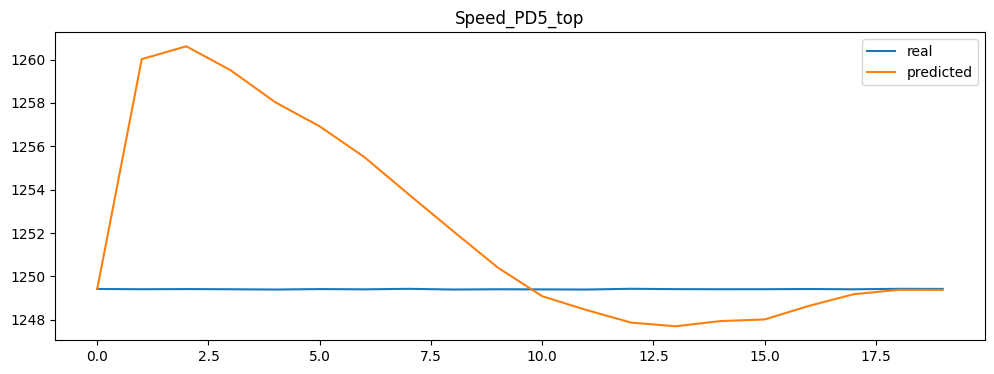

In [46]:
import matplotlib.pyplot as plt

var = 'Speed_PD5_top'

plt.figure(figsize=(12, 4))
plt.plot(true_states[var].values, label="real")
plt.plot(pred_states[var].values, label="predicted")
plt.legend()
plt.title(var)
plt.show()


In [48]:
ctl_vars = list(set(control_vars['Steam_flow_to_AfterDryers'] + control_vars['Steam_flow_to_PreDryers']))
created_vars=[            
            "Water_flow_Predryer",
            "Water_flow_Afterdryer",
            "Water_flow",
            "flow_diluted_starch",
            "Fibre__g/m2_",
            "Water_flow_Afterdryer_input", 
            "Water_flow_Afterdryer_output",
            "dewatering",
        ]

created_vars = list(set(created_vars).intersection(set(ctl_vars)))

continuous_data = pd.read_parquet(f"data/costimier_continuous.parquet", columns = cvars)
continuous_data["concentration_starch_working_tank_1"]=continuous_data["Flow_starch_main_line_to_working_tank_1~^0"]/(continuous_data["Dilution_water_working_tank_1"]+continuous_data["Flow_starch_main_line_to_working_tank_1~^0"])
continuous_data["concentration_starch_working_tank_2"]=continuous_data["Flow_starch_main_line_to_working_tank_2~^0"]/(continuous_data["Dilution_water_working_tank_2"]+continuous_data["Dilution_water_working_tank_1"])
continuous_data["retention"]=1-continuous_data['Consistency_white_water']/(10*continuous_data['Headbox_consistency'])

if len(created_vars)>0:
    fc = FeatureCreator(features_to_create=created_vars, features_to_keep= list(set(continuous_data.columns.to_list()+created_vars)))
    continuous_data = fc.fit_transform(continuous_data)
    fr = fc.features_required()
else:
    fr=[]

In [69]:
created_vars

['Starch_uptake__g/m2_', 'delta_basis_weight']

In [86]:
black_list = []

prep_pip, s_vars = make_prep_pip(prefixes=["draw", "speedsizer_linepressure", "linepressure", "conc_starch"])
ctl_vars = list(set(control_vars["MBS_SCT_CD"]))
created_vars=[
            "delta_basis_weight",
            "Starch_uptake__g/m2_",
            "Water_flow_Predryer",
            "Water_flow_Afterdryer",
            "Water_flow",
            "flow_diluted_starch",
            "Fibre__g/m2_",
            "Water_flow_Afterdryer_input", 
            "Water_flow_Afterdryer_output",
            "dewatering",
            'fibre_short/long'
        ]

created_vars = list(set(created_vars).intersection(set(ctl_vars)))

continuous_data = pd.read_parquet(f"data/costimier_continuous.parquet", columns = cvars + ["AB_Grade_ID", "MBS_SCT_CD"])
continuous_data["concentration_starch_working_tank_1"]=continuous_data["Flow_starch_main_line_to_working_tank_1~^0"]/(continuous_data["Dilution_water_working_tank_1"]+continuous_data["Flow_starch_main_line_to_working_tank_1~^0"])
continuous_data["concentration_starch_working_tank_2"]=continuous_data["Flow_starch_main_line_to_working_tank_2~^0"]/(continuous_data["Dilution_water_working_tank_2"]+continuous_data["Dilution_water_working_tank_1"])
continuous_data["retention"]=1-continuous_data['Consistency_white_water']/(10*continuous_data['Headbox_consistency'])
continuous_data["grammage"]=continuous_data["AB_Grade_ID"].apply(lambda s: s-int(s/1000)*1000 )

if len(created_vars)>0:
    fc = FeatureCreator(features_to_create=created_vars, features_to_keep= list(set(continuous_data.columns.to_list()+created_vars)))
    continuous_data = fc.fit_transform(continuous_data)
    fr = fc.features_required()
else:
    fr=[]

continuous_data = continuous_data.set_index("Wedge_Time")
continuous_data["grammage"] = continuous_data["grammage"]

exog_vars = list(set(ctl_vars + fr + ["grammage"] + s_vars)) 

candidate_lags = None

extra_vars = ["AB_Grade_ID","MBS_SCT_CD"]

candidate_lags = None

lags = 0
filter = True

steam_pressure = [v for v in continuous_data.columns if re.compile(r"cylinder.*steam_pressure", re.IGNORECASE).search(v)]
steam_diff_pressure = [v for v in continuous_data.columns if re.compile(r"cylinder.*differential_pressure", re.IGNORECASE).search(v)]

fixed_features = ["grammage","Starch_uptake__g/m2_","delta_basis_weight","Jet/wire_ratio"] 
#fixed_features = ["Water_flow_Predryer","Water_flow_Afterdryer_input"] 
#fixed_features = ["grammage"] 
#fixed_features = [] 
exog_vars_ = fixed_features + [v for v in exog_vars if v not in black_list and v not in fr]
exog_vars_ = list(set(exog_vars_) - set(steam_pressure + steam_diff_pressure))
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        #fixed_features += var_trafo
        exog_vars_ = list(set(exog_vars_ + var_trafo) - set(var_in))


exog_vars_ = list(set(fixed_features + exog_vars_) )

In [76]:
exog_vars_

['pH_measurement_white_water_B41',
 'Speed',
 'Starch_uptake__g/m2_',
 'grammage',
 'Current_reel_width',
 'Current_reel_moisture_average(reel)',
 'CO2_mass_flow__g/T_',
 'Moisture_after_SpeedSizer',
 'draw_1',
 'draw_2',
 'linepressure_1',
 'Conductivity_white_water_B46',
 'White_water_temperature',
 'delta_basis_weight',
 'Headbox_consistency',
 'Bentonite_2_mass_flow__g/T_',
 'conc_starch_1',
 'fibre_short/long',
 'Jet/wire_ratio',
 'Retention_Aid_mass_flow__g/T_',
 'Bentonite_1_mass_flow__g/T_',
 'Lip_settings',
 'Consistency_starch_main_line',
 'retention',
 'speedsizer_linepressure_1']

In [77]:
actionable_inputs = [
    'pH_measurement_white_water_B41',
 'Speed',
 'Starch_uptake__g/m2_',
 'grammage',
 'Current_reel_width',
 'Current_reel_moisture_average(reel)',
 'CO2_mass_flow__g/T_',
 'Moisture_after_SpeedSizer',
 'linepressure_1',
 'delta_basis_weight',
 'Headbox_consistency',
 'Bentonite_2_mass_flow__g/T_',
 'conc_starch_1',
 'fibre_short/long',
 'Jet/wire_ratio',
 'Retention_Aid_mass_flow__g/T_',
 'Bentonite_1_mass_flow__g/T_',
 'Lip_settings',
 'Consistency_starch_main_line',
 'speedsizer_linepressure_1']

In [68]:
'Water_flow_Predryer' in continuous_data.columns.to_list()

False

In [88]:
s_vars=[v for v in exog_vars_ if v!="grammage"]
features_to_keep_feat = s_vars
features_to_keep_filter = s_vars
for i in range(len(prep_pip.steps)):    
    _, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        s_vars_step = list(set(s_vars).intersection(set(var_trafo)))
        
        if len(s_vars_step) > 0:
            
            s_vars = list(set(s_vars) - set(s_vars_step) ) 
            features_to_keep_feat = list(set(features_to_keep_feat) - set(s_vars_step)) 
            features_to_keep_filter = list(set(features_to_keep_filter) - set(s_vars_step)) 
            features_to_keep_feat = features_to_keep_feat + var_in
            features_to_keep_filter = features_to_keep_filter + s_vars_step
    
features_to_create = [v for v in created_vars if v in  s_vars]
n_max=len(s_vars)

max_comps = 10 # min(20, len(exog_vars))
pre_estimator = Pipeline(steps=[])
pre_estimator.steps.append(("feat", FeatureCreator(features_to_create=features_to_create, features_to_keep=list(set(features_to_keep_feat)) ,errors="raise")))
for i in range(len(prep_pip.steps)):
    name_step, step = prep_pip.steps[i]
    if type(step) is GroupwisePLSTransformer:
        var_trafo = [f"{step.score_prefix}_{i}" for i in range(1,step.n_components+1)]
        var_in = list(step.pls_columns)
        if len(list(set(features_to_keep_filter).intersection(set(var_trafo)))) > 0:        
            pre_estimator.steps.append((name_step, step))
    else:
        pre_estimator.steps.append((name_step, step))
#pre_estimator.steps.append(("filter", FeatureCreator(features_to_create=[], features_to_keep=list(set(features_to_keep_filter)),errors="raise")))
pre_estimator.steps.append(("filter", SKColumnSelector(list(set(features_to_keep_filter)))))


feat_list = list(set(features_to_keep_feat + pre_estimator.named_steps["feat"].features_required()) - set(features_to_create))

continuous_data__ = continuous_data[feat_list + ["MBS_SCT_CD"]].dropna()
pre_estimator.fit(continuous_data__[feat_list], continuous_data__["MBS_SCT_CD"])

continuous_data__ = pre_estimator.transform(continuous_data[feat_list])

In [96]:
dmdc_pack = fit_dmdc_process_model(
    continuous_sample=continuous_data__,
    actionable_inputs=actionable_inputs,
    time_col="Wedge_Time", # use None if already sorted
    train_size=0.8,
    svd_rank=2,
    ridge_alpha=10.0,
    stabilize=True,
    max_abs_eig=0.98,
)

one_step_metrics = evaluate_dmdc_one_step(dmdc_pack)

recursive_metrics, true_states, pred_states = evaluate_dmdc_recursive(
    dmdc_pack,
    horizon=20,
)

horizon_metrics = evaluate_horizons(
    dmdc_pack,
    horizons=(5, 10, 20, 50, 100, 200),
)

In [97]:
horizon_metrics

,horizon,median_r2,median_rmse,mean_r2
0,5,-2.729962,0.047549,-467.619225
1,10,-5.685194,0.075980,-500.950106
2,20,-9.696377,0.116345,-467.089435
3,50,-27.984550,0.210225,-205.395619
4,100,-20.345979,0.286447,-156.790425
5,200,-9.867401,0.288902,-309.530255


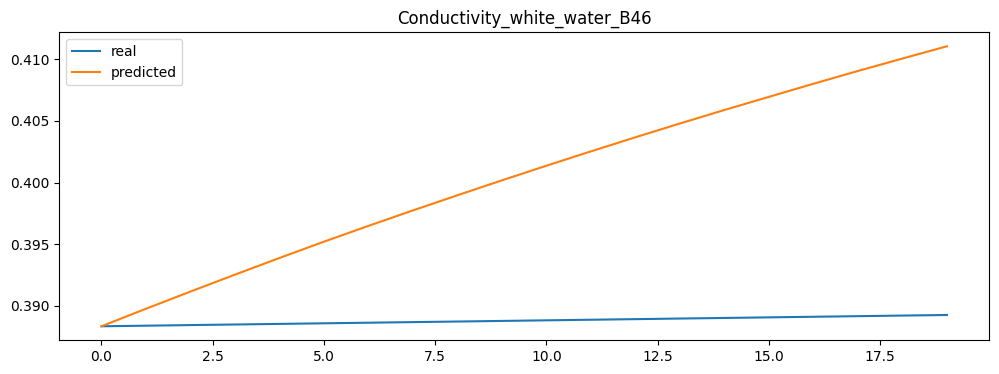

In [98]:
import matplotlib.pyplot as plt

var = 'Conductivity_white_water_B46'

plt.figure(figsize=(12, 4))
plt.plot(true_states[var].values, label="real")
plt.plot(pred_states[var].values, label="predicted")
plt.legend()
plt.title(var)
plt.show()